In [1]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_order = pd.read_csv('ab_orders.csv')
df_order.head()

,order_id,creation_time,product_ids
0,1255,2022-08-26 00:00:19.000000,"{75, 22, 53, 84}"
1,1256,2022-08-26 00:02:21.000000,"{56, 76, 39}"
2,1257,2022-08-26 00:02:27.000000,"{76, 34, 41, 38}"
3,1258,2022-08-26 00:02:56.000000,"{74, 6}"
4,1259,2022-08-26 00:03:37.000000,"{20, 45, 67, 26}"


In [3]:
df_order.shape[0]

4123

In [4]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4123 entries, 0 to 4122
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_id       4123 non-null   int64 
 1   creation_time  4123 non-null   object
 2   product_ids    4123 non-null   object
dtypes: int64(1), object(2)
memory usage: 96.8+ KB


In [5]:
df_order['creation_time'] = pd.to_datetime(df_order['creation_time']).dt.strftime('%Y-%m-%d')

In [6]:
def make_int(row):
    return[int(x) for x in row.strip('{}').split((', '))]
df_order['product_ids'] = df_order['product_ids'].apply(make_int)

In [7]:
df_order

,order_id,creation_time,product_ids
0,1255,2022-08-26,"[75, 22, 53, 84]"
1,1256,2022-08-26,"[56, 76, 39]"
2,1257,2022-08-26,"[76, 34, 41, 38]"
3,1258,2022-08-26,"[74, 6]"
4,1259,2022-08-26,"[20, 45, 67, 26]"
...,...,...,...
4118,59422,2022-09-08,"[84, 8, 24]"
4119,59439,2022-09-08,"[9, 25, 75, 30, 6]"
4120,59464,2022-09-08,"[60, 41, 46]"
4121,59487,2022-09-08,"[9, 62, 77]"


In [8]:
df_order['creation_time'] = pd.to_datetime(df_order['creation_time'])

In [9]:
df_order.dtypes

order_id                  int64
creation_time    datetime64[ns]
product_ids              object
dtype: object

In [10]:
df_orders_exp = df_order.explode('product_ids')

In [11]:
df_products = pd.read_csv('ab_products.csv')
df_products.head()

,product_id,name,price
0,1,сахар,150.0
1,2,чай зеленый в пакетиках,50.0
2,3,вода негазированная,80.4
3,4,леденцы,45.5
4,5,кофе 3 в 1,15.0


In [12]:
df_products.shape

(87, 3)

In [13]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   product_id  87 non-null     int64  
 1   name        87 non-null     object 
 2   price       87 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 2.2+ KB


In [14]:
df_users = pd.read_csv('ab_users_data.csv')
df_users.head()

,user_id,order_id,action,time,date,group
0,964,1255,create_order,2022-08-26 00:00:19.000000,2022-08-26,0
1,965,1256,create_order,2022-08-26 00:02:21.000000,2022-08-26,1
2,964,1257,create_order,2022-08-26 00:02:27.000000,2022-08-26,0
3,966,1258,create_order,2022-08-26 00:02:56.000000,2022-08-26,0
4,967,1259,create_order,2022-08-26 00:03:37.000000,2022-08-26,1


In [15]:
df_users = df_users.drop('time', axis=1)

In [16]:
df_users['date'] = pd.to_datetime(df_users['date'])

In [17]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4337 entries, 0 to 4336
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   4337 non-null   int64         
 1   order_id  4337 non-null   int64         
 2   action    4337 non-null   object        
 3   date      4337 non-null   datetime64[ns]
 4   group     4337 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 169.5+ KB


In [18]:
df_users.action.unique()

array(['create_order', 'cancel_order'], dtype=object)

In [19]:
df_users.action.value_counts()

action
create_order    4123
cancel_order     214
Name: count, dtype: int64

In [20]:
# кол-во отказов по группам
df_users.query('action == "cancel_order"').groupby('group', as_index=False)['user_id'].count()

,group,user_id
0,0,82
1,1,132


### во второй группе чаще отказываются от заказаов

In [21]:
df = df_orders_exp.merge(df_users, on='order_id',how='left').merge(df_products, how='left', left_on='product_ids', right_on='product_id')
df.head()

,order_id,creation_time,product_ids,user_id,action,date,group,product_id,name,price
0,1255,2022-08-26,75,964,create_order,2022-08-26,0,75,сок ананасовый,120.0
1,1255,2022-08-26,22,964,create_order,2022-08-26,0,22,сок мультифрукт,120.0
2,1255,2022-08-26,53,964,create_order,2022-08-26,0,53,мука,78.3
3,1255,2022-08-26,84,964,create_order,2022-08-26,0,84,мандарины,90.4
4,1256,2022-08-26,56,965,create_order,2022-08-26,1,56,сосиски,150.0


In [22]:
df = df.drop(['product_ids', 'date'], axis=1)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14569 entries, 0 to 14568
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       14569 non-null  int64         
 1   creation_time  14569 non-null  datetime64[ns]
 2   user_id        14569 non-null  int64         
 3   action         14569 non-null  object        
 4   group          14569 non-null  int64         
 5   product_id     14569 non-null  int64         
 6   name           14569 non-null  object        
 7   price          14569 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 910.7+ KB


/var/folders/_q/y78js8613z37pq4ldhx06pc00000gn/T/ipykernel_15888/3777559328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_users_count, x='group', y='number_of_users', palette=['lightgreen', 'lightblue'])


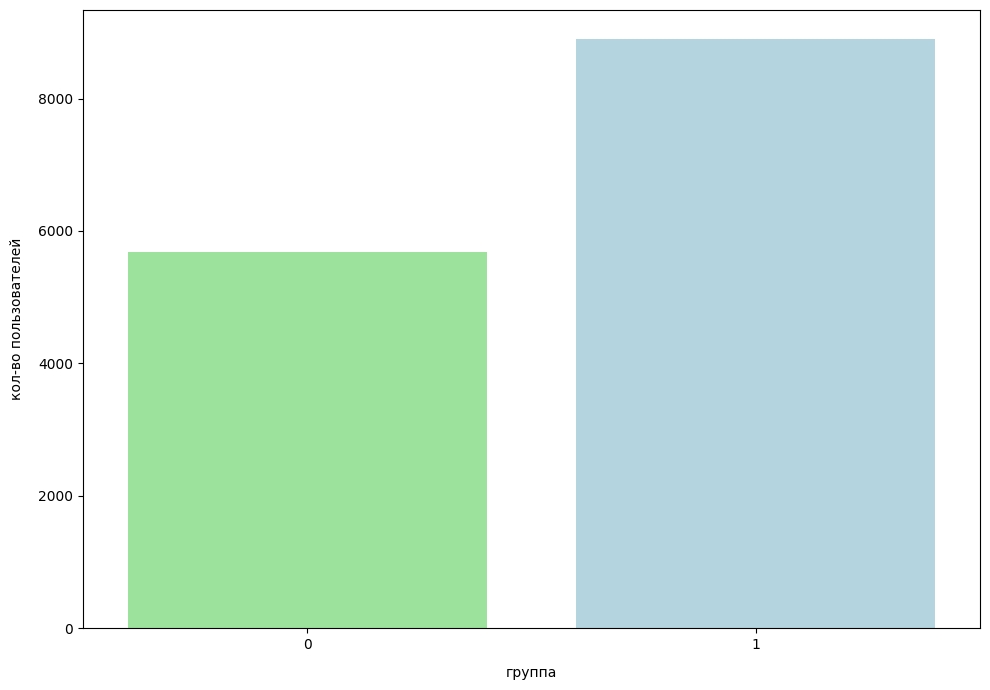

In [ ]:
df_users_count = df.groupby('group', as_index=False)['order_id'].count().rename(columns={'order_id':'number_of_users'})

#визуализация распредления пользователей по группам
plt.figure(figsize=(10,7))
sns.barplot(data=df_users_count, x='group', y='number_of_users', palette=['lightgreen', 'lightblue'])
plt.xlabel('группа', labelpad=10)
plt.ylabel('кол-во пользователей', labelpad=10)
plt.tight_layout()
plt.show()

In [25]:
df_group1 = df[df['group'] == 1]
df_group0 = df[df['group'] == 0]

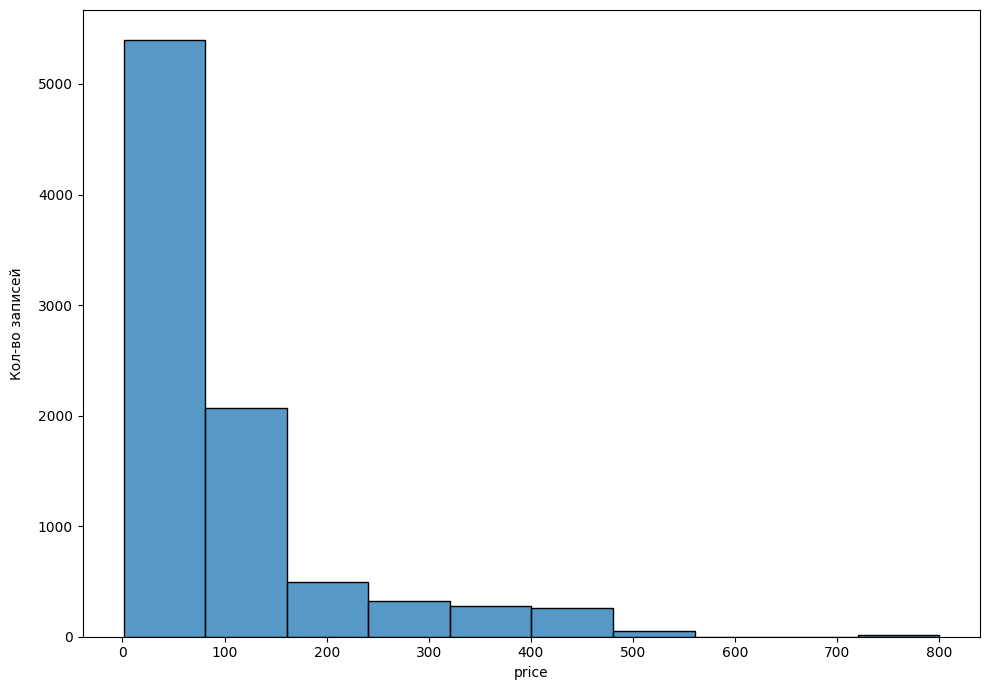

In [49]:
#дисперсия цен в группе 1
plt.figure(figsize=(10,7))
sns.histplot(df_group1['price'], bins=10)
plt.ylabel('Кол-во записей', labelpad=10)
plt.tight_layout()
plt.show()

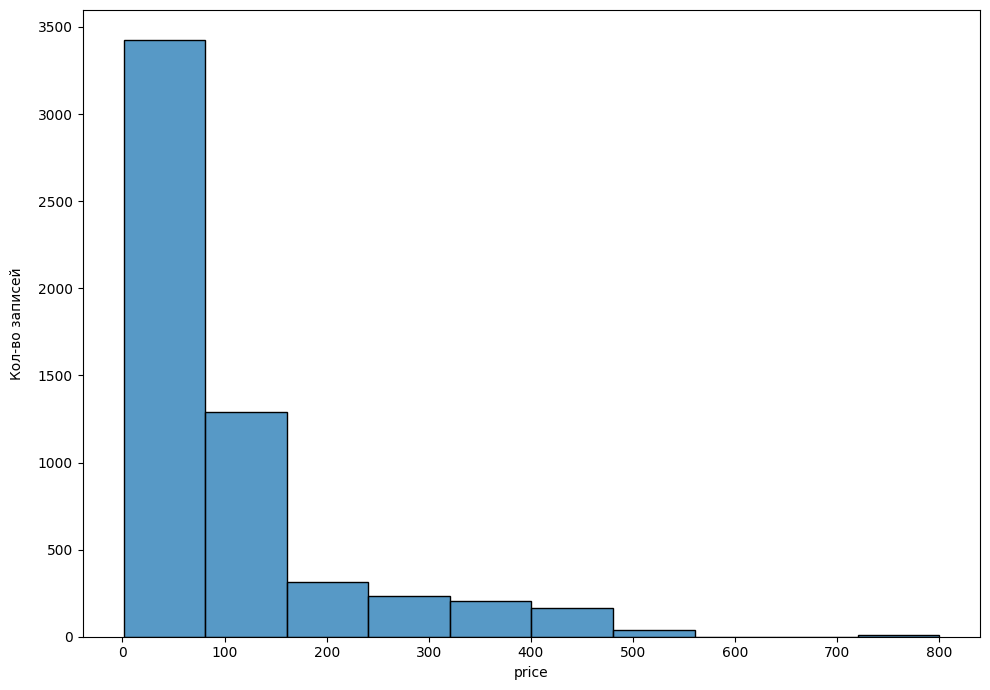

In [48]:
#дисперсия цен в группе 0
plt.figure(figsize=(10,7))
sns.histplot(df_group0['price'], bins=10)
plt.ylabel('Кол-во записей', labelpad=10)
plt.tight_layout()
plt.show()

In [28]:
df_group0.head()

,order_id,creation_time,user_id,action,group,product_id,name,price
0,1255,2022-08-26,964,create_order,0,75,сок ананасовый,120.0
1,1255,2022-08-26,964,create_order,0,22,сок мультифрукт,120.0
2,1255,2022-08-26,964,create_order,0,53,мука,78.3
3,1255,2022-08-26,964,create_order,0,84,мандарины,90.4
7,1257,2022-08-26,964,create_order,0,76,чай черный в пакетиках,55.5


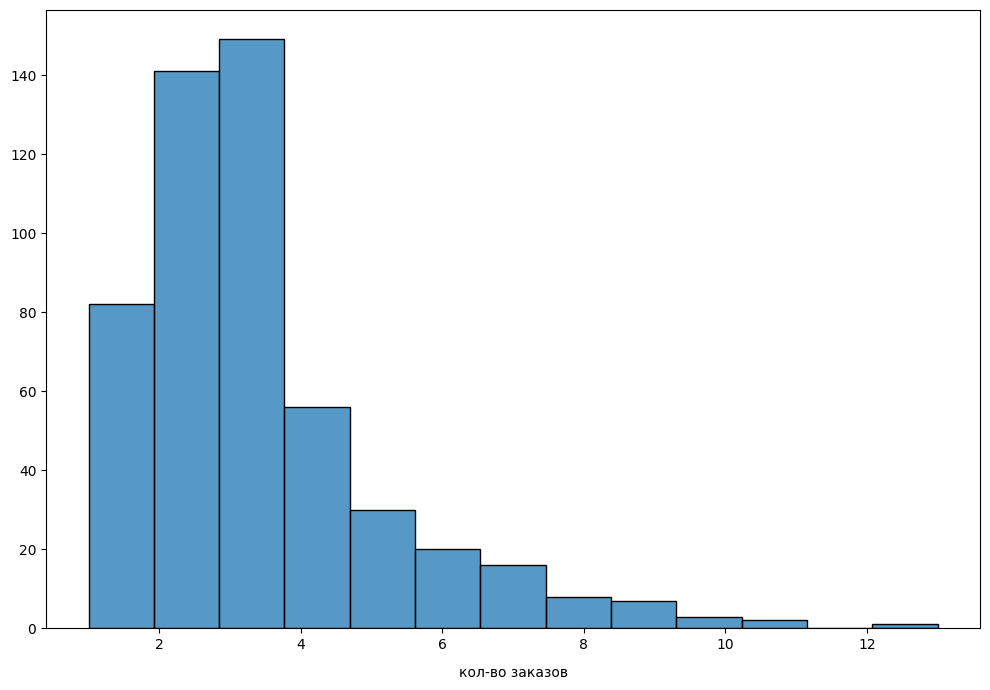

In [ ]:
# кол-во заказов на пользователя в первой группе
df_succ_0 = df_group0.query('action == "create_order"').groupby('user_id', as_index=False)['order_id'].nunique().rename(columns={'order_id':'number_of_orders'})
plt.figure(figsize=(10,7))
sns.histplot(df_succ_0['number_of_orders'], bins=13)
plt.xlabel('кол-во заказов', labelpad=10)
plt.ylabel('', labelpad=10)
plt.tight_layout()
plt.show()

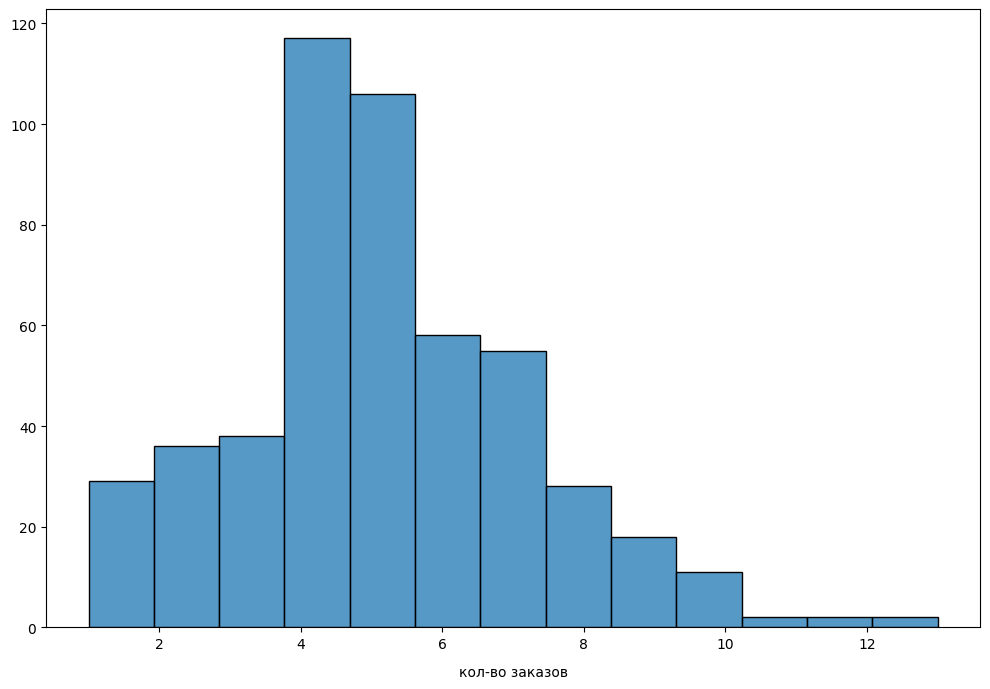

In [ ]:
# кол-во заказов на пользовтаеля во второй группе
df_succ_1 = df_group1.query('action == "create_order"').groupby('user_id', as_index=False)['order_id'].nunique().rename(columns={'order_id':'number_of_orders'})
plt.figure(figsize=(10,7))
sns.histplot(df_succ_1['number_of_orders'], bins=13)
plt.xlabel('кол-во заказов', labelpad=10)
plt.ylabel('', labelpad=10)
plt.tight_layout()
plt.show()

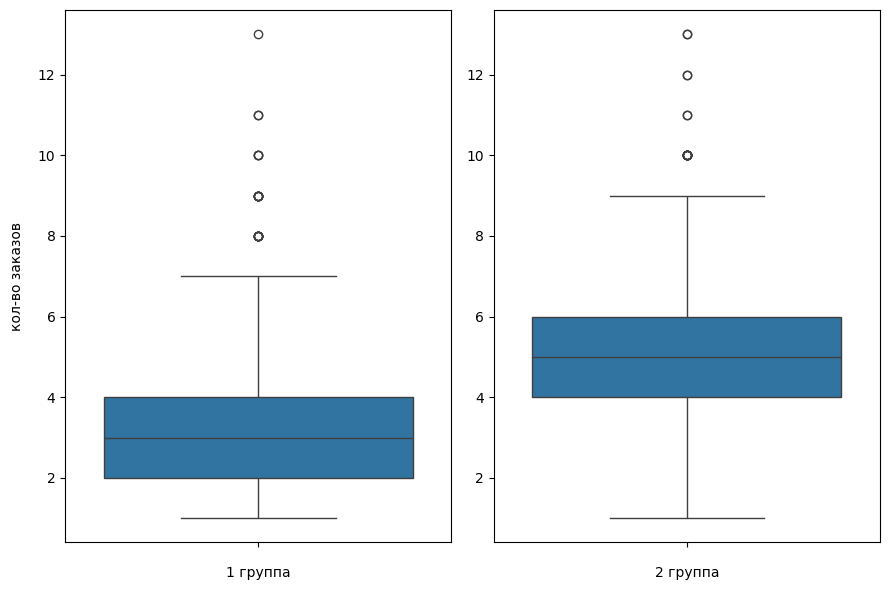

In [46]:
# ящик с усами для двух групп
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 6))

# 1 группа
sns.boxplot(df_succ_0['number_of_orders'], ax=ax1)
ax1.set_xlabel('1 группа', labelpad=10)
ax1.set_ylabel('кол-во заказов', labelpad=10)

# 2 группа
sns.boxplot(df_succ_1['number_of_orders'], ax=ax2)
ax2.set_xlabel('2 группа', labelpad=10)
ax2.set_ylabel('', labelpad=10)

plt.tight_layout()
plt.show()

# Случайно ли пользователи второй группы заказывают чаще?
## H0: Случайно, пропорции равны
## H1: Нет, не случайно, различия стат. значимы

In [ ]:
# проводим z-тест для пропорций
from statsmodels.stats.proportion import proportions_ztest
success = [df_succ_0.shape[0], df_succ_1.shape[0]]
nobs = [df_group0.shape[0], df_group1.shape[0]]
z_value, p_value = proportions_ztest(success, nobs)
print(f"Z статистика: {z_value:.3f}")
print(f"p-value: {p_value}")

Z статистика: 7.430
p-value: 1.0895187580424048e-13


### На основе теста мы можем судить о том, что существует стат. значимые различия в пропорциях двух групп

## Далее проверим средний чек каждого заказа и посмотрим различается ли он в двух группах

In [50]:
df_group0.head()

,order_id,creation_time,user_id,action,group,product_id,name,price
0,1255,2022-08-26,964,create_order,0,75,сок ананасовый,120.0
1,1255,2022-08-26,964,create_order,0,22,сок мультифрукт,120.0
2,1255,2022-08-26,964,create_order,0,53,мука,78.3
3,1255,2022-08-26,964,create_order,0,84,мандарины,90.4
7,1257,2022-08-26,964,create_order,0,76,чай черный в пакетиках,55.5


In [53]:
# 1 группа
df_price_0 = df_group0.groupby('order_id', as_index=False)['price'].sum().sort_values(['price'],ascending=False).rename(columns={'price':'total_price'}).reset_index(drop=True)
df_price_0

,order_id,total_price
0,2553,1722.8
1,24404,1722.8
2,16992,1668.6
3,53610,1636.6
4,2691,1546.6
...,...,...
1604,26188,30.0
1605,39503,25.0
1606,1716,25.0
1607,12361,15.0


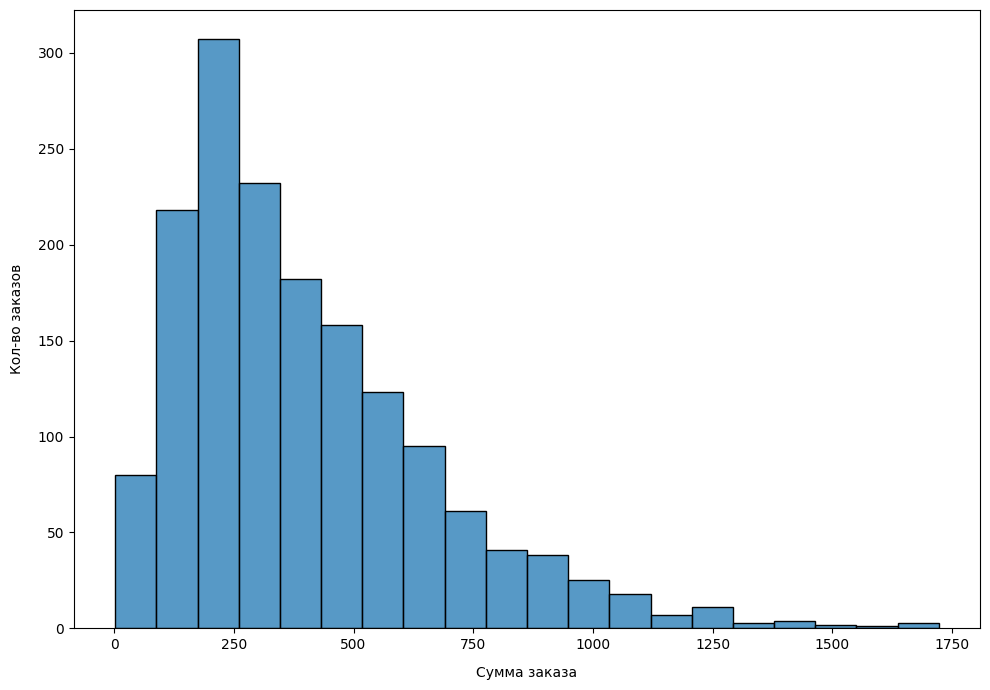

In [60]:
# визуализация распределения суммы заказа в 1 группе
plt.figure(figsize=(10,7))
sns.histplot(df_price_0['total_price'], bins=20)
plt.xlabel('Сумма заказа', labelpad=10)
plt.ylabel('Кол-во заказов', labelpad=10)
plt.tight_layout()
plt.show()

In [56]:
# 2 группа
df_price_1 = df_group1.groupby('order_id', as_index=False)['price'].sum().sort_values(['price'],ascending=False).rename(columns={'price':'total_price'}).reset_index(drop=True)
df_price_1

,order_id,total_price
0,34135,2412.8
1,1805,2330.0
2,1308,2050.0
3,21991,2020.8
4,15352,1930.2
...,...,...
2509,4487,15.0
2510,7948,15.0
2511,25971,12.0
2512,1306,12.0


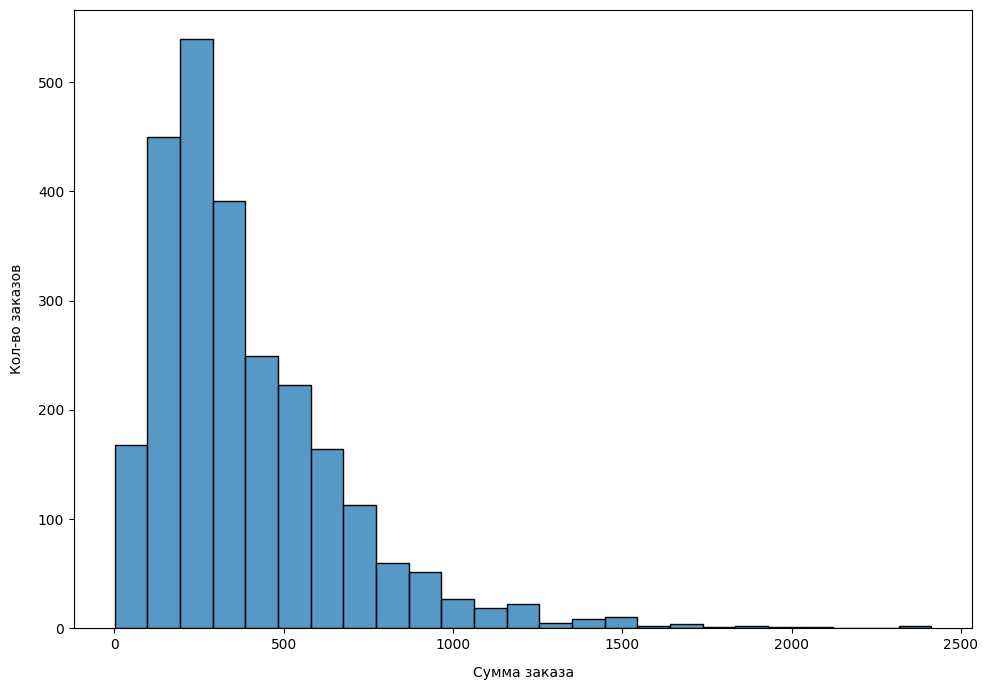

In [62]:
# визуализация распределения суммы заказа в 2 группе
plt.figure(figsize=(10,7))
sns.histplot(df_price_1['total_price'], bins=25)
plt.xlabel('Сумма заказа', labelpad=10)
plt.ylabel('Кол-во заказов', labelpad=10)
plt.tight_layout()
plt.show()